In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.semi_supervised import LabelSpreading

In [2]:
df = pd.read_csv('../data/processed/data_cleaned.csv')

print("Shape:", df.shape)
df.head()

Shape: (2666, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,-0.024698,0.276380,-0.087788,0.133760,1.318170,1.731801,-1.220488,1.379017,-1.312414,0
1,0.849411,0.958501,-0.199087,1.531834,-0.019184,-0.090093,0.796898,-0.001966,-1.190445,0
2,1.028484,0.610743,0.067098,0.670947,0.879328,-0.782072,1.284355,2.275289,0.876799,0
3,1.666523,-0.562404,-0.442764,-0.399530,-0.884687,-0.342620,-0.854093,-2.312822,0.149055,0
4,-1.219937,-0.308120,0.916600,0.306890,-0.260491,-1.817403,-1.836085,-0.774144,-1.842654,0


In [3]:
X = df.drop('Potability', axis=1)
y = df['Potability']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

acc_log = accuracy_score(y_test, y_pred_log)
pre_log = precision_score(y_test, y_pred_log)
rec_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)

print("Logistic Regression:")
print(classification_report(y_test, y_pred_log))

Logistic Regression:
              precision    recall  f1-score   support

           0       0.63      1.00      0.77       335
           1       0.00      0.00      0.00       199

    accuracy                           0.63       534
   macro avg       0.31      0.50      0.39       534
weighted avg       0.39      0.63      0.48       534



c:\Users\Admin\anaconda3\envs\datamining\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\anaconda3\envs\datamining\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\anaconda3\envs\datamining\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", resul

In [6]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
pre_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest:")
print(classification_report(y_test, y_pred_rf))

Random Forest:
              precision    recall  f1-score   support

           0       0.67      0.89      0.76       335
           1       0.58      0.26      0.36       199

    accuracy                           0.65       534
   macro avg       0.62      0.57      0.56       534
weighted avg       0.63      0.65      0.61       534



In [7]:
# tạo bản semi label
y_semi = y_train.copy()

# giữ lại 10% label
mask = np.random.rand(len(y_semi)) < 0.9
y_semi[mask] = -1

semi_model = LabelSpreading()
semi_model.fit(X_train, y_semi)

y_pred_semi = semi_model.predict(X_test)

acc_semi = accuracy_score(y_test, y_pred_semi)
pre_semi = precision_score(y_test, y_pred_semi)
rec_semi = recall_score(y_test, y_pred_semi)
f1_semi = f1_score(y_test, y_pred_semi)

print("Semi-supervised:")
print(classification_report(y_test, y_pred_semi))

Semi-supervised:
              precision    recall  f1-score   support

           0       0.63      0.68      0.66       335
           1       0.38      0.32      0.35       199

    accuracy                           0.55       534
   macro avg       0.50      0.50      0.50       534
weighted avg       0.53      0.55      0.54       534



In [8]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Semi-supervised"],
    "Accuracy": [acc_log, acc_rf, acc_semi],
    "Precision": [pre_log, pre_rf, pre_semi],
    "Recall": [rec_log, rec_rf, rec_semi],
    "F1-score": [f1_log, f1_rf, f1_semi]
})

results

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.627341,0.000000,0.000000,0.000000
1,Random Forest,0.653558,0.577778,0.261307,0.359862
2,Semi-supervised,0.548689,0.376471,0.321608,0.346883


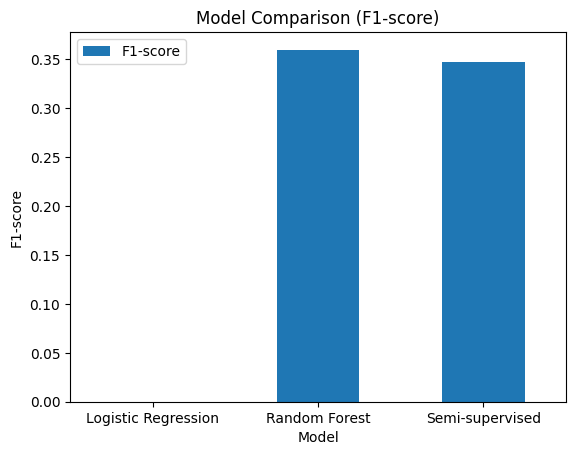

In [9]:
results.set_index("Model")[["F1-score"]].plot(kind="bar")
plt.title("Model Comparison (F1-score)")
plt.ylabel("F1-score")
plt.xticks(rotation=0)
plt.show()

Random Forest đạt hiệu suất cao nhất nhờ khả năng mô hình hóa các quan hệ phi tuyến giữa các đặc trưng của nước.

Logistic Regression hoạt động kém hơn do giả định tuyến tính không phù hợp với dữ liệu thực tế.

Mô hình Semi-supervised cho thấy hiệu quả đáng kể trong điều kiện thiếu dữ liệu gán nhãn, cho kết quả gần tương đương với mô hình học có giám sát.

=>Random Forest là lựa chọn tốt nhất cho bài toán phân loại chất lượng nước.